In [63]:
import pandas as pd
import numpy as np
import spacy
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from textstat import flesch_reading_ease
from collections import Counter
from os import walk
import os
from pathlib import Path
from tqdm import tqdm


In [64]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 960.0 kB/s eta 0:00:14
      --------------------------------------- 0.2/12.8 MB 2.0 MB/s eta 0:00:07
     - -------------------------------------- 0.4/12.8 MB 3.4 MB/s eta 0:00:04
     -- ------------------------------------- 0.8/12.8 MB 4.3 MB/s eta 0:00:03
     --- ------------------------------------ 1.2/12.8 MB 4.9 MB/s eta 0:00:03
     ---- ----------------------------------- 1.4/12.8 MB 5.0 MB/s eta 0:00:03
     ---- ----------------------------------- 1.6/12.8 MB 4.8 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.8 MB 4.9 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.8 MB 4.9 MB/s eta 0:00:03
     ------ --------------------------------- 2.1/12.8 MB 4.5 MB/s eta 0:00:03
     ------- -------------------------------- 2.5/12.8 MB 4.8 MB/

In [65]:
nlp = spacy.load("en_core_web_sm")

In [66]:
LLMS = ['bloomz', 'chatgpt', 'cohere', 'davinci', 'human']

In [67]:

# Function to extract stylometric features
def extract_stylometric_features(text):
    doc = nlp(text)
    
    # Lexical Features
    word_count = len([token.text for token in doc if token.is_alpha])
    avg_word_length = np.mean([len(token.text) for token in doc if token.is_alpha]) if word_count > 0 else 0
    
    # Syntactic Features
    sentence_count = len(list(doc.sents))
    avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0
    pos_counts = Counter([token.pos_ for token in doc])
    noun_ratio = pos_counts["NOUN"] / word_count if word_count > 0 else 0
    verb_ratio = pos_counts["VERB"] / word_count if word_count > 0 else 0
    adj_ratio = pos_counts["ADJ"] / word_count if word_count > 0 else 0
    
    # Character-Level Features
    uppercase_ratio = sum(1 for token in doc if token.text.isupper()) / word_count if word_count > 0 else 0
    punctuation_ratio = sum(1 for token in doc if token.is_punct) / word_count if word_count > 0 else 0
    
    # Readability Score
    readability = flesch_reading_ease(text)

    # Return features as a dictionary
    return {
        "word_count": word_count,
        "avg_word_length": avg_word_length,
        "sentence_count": sentence_count,
        "avg_sentence_length": avg_sentence_length,
        "noun_ratio": noun_ratio,
        "verb_ratio": verb_ratio,
        "adj_ratio": adj_ratio,
        "uppercase_ratio": uppercase_ratio,
        "punctuation_ratio": punctuation_ratio,
        "readability": readability,
    }


In [68]:
df = pd.DataFrame(columns=['text', 'is_llm', 'domain', 'dataset_name'])

dir_path, dir_names, file_names = next(walk('../../data/raw/m4-unified'))

for dir in dir_names:
    dataset_folder_path, _, dataset_names = next(walk(os.path.join(dir_path, dir)))
    for dataset_name in dataset_names:
        temp_df = pd.read_json(path_or_buf=f'{dataset_folder_path}/{dataset_name}', lines=True)
        temp_df['domain'] = dir
        temp_df['dataset_name'] = Path(dataset_name).stem
        temp_df['author'] = Path(dataset_name).stem.split('_')[1]

        if Path(dataset_name).stem.split('_')[1].lower() not in LLMS:
          continue
        temp_df['is_llm'] = 0 if 'human' in dataset_name else 1
        print(dataset_name, 0 if 'human' in dataset_name else 1 )
        df = pd.concat([df, temp_df], ignore_index=True)

arxiv_bloomz.jsonl 1
arxiv_chatGPT.jsonl 1
arxiv_cohere.jsonl 1
arxiv_davinci.jsonl 1
arxiv_human.jsonl 0
reddit_bloomz.jsonl 1
reddit_chatGPT.jsonl 1
reddit_cohere.jsonl 1
reddit_davinci.jsonl 1
reddit_human.jsonl 0
wikihow_bloomz.jsonl 1
wikihow_chatGPT.jsonl 1
wikihow_cohere.jsonl 1
wikihow_davinci.jsonl 1
wikihow_human.jsonl 0
wikipedia_bloomz.jsonl 1
wikipedia_chatGPT.jsonl 1
wikipedia_cohere.jsonl 1
wikipedia_davinci.jsonl 1
wikipedia_human.jsonl 0


In [69]:
sampled_df = df.groupby('dataset_name', group_keys=False).apply(lambda x: x.sample(min(len(x), 300), random_state = 42))
sampled_df

C:\Users\boyan.bogdanov\AppData\Local\Temp\ipykernel_7560\221845010.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('dataset_name', group_keys=False).apply(lambda x: x.sample(min(len(x), 300), random_state = 42))


,text,is_llm,domain,dataset_name,author
1801,We present the first results for effective-one...,1,arxiv,arxiv_bloomz,bloomz
1190,We propose to cool fermionic atoms in optical ...,1,arxiv,arxiv_bloomz,bloomz
1817,We use hydrodynamic simulations to study how p...,1,arxiv,arxiv_bloomz,bloomz
251,We present an analysis of the evolution of ear...,1,arxiv,arxiv_bloomz,bloomz
2505,We report the discovery of massive outflows (1...,1,arxiv,arxiv_bloomz,bloomz
...,...,...,...,...,...
59079,La Roche-en-Ardenne Castle () is a ruined medi...,0,wikipedia,wikipedia_human,human
58120,"Herbert Henry Woollard, FRS (2 August 1889 – 1...",0,wikipedia,wikipedia_human,human
57885,Hari Dev Shourie (1911–2005) was a well-known ...,0,wikipedia,wikipedia_human,human
57309,"Michael J. Reasoner (born August 17, 1960) is ...",0,wikipedia,wikipedia_human,human


In [72]:
tqdm.pandas()
# Extract features for all texts
feature_dicts = sampled_df["text"].progress_apply(extract_stylometric_features)
feature_df = pd.DataFrame(feature_dicts.tolist())  # Convert list of dicts to DataFrame


100%|██████████| 6000/6000 [05:46<00:00, 17.31it/s]


In [73]:
data = pd.concat([feature_df.reset_index(), sampled_df["is_llm"].reset_index()], axis=1)
data.drop(columns=["index"], inplace=True)
data['is_llm'].value_counts()

is_llm
1    4800
0    1200
Name: count, dtype: int64

In [74]:
X = data.drop(columns=["is_llm"])
y = data["is_llm"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
# Train an XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [76]:
# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred
y_test = y_test.to_numpy().astype(int)


Accuracy: 0.8342
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.35      0.44       220
           1       0.87      0.94      0.90       980

    accuracy                           0.83      1200
   macro avg       0.72      0.65      0.67      1200
weighted avg       0.81      0.83      0.82      1200



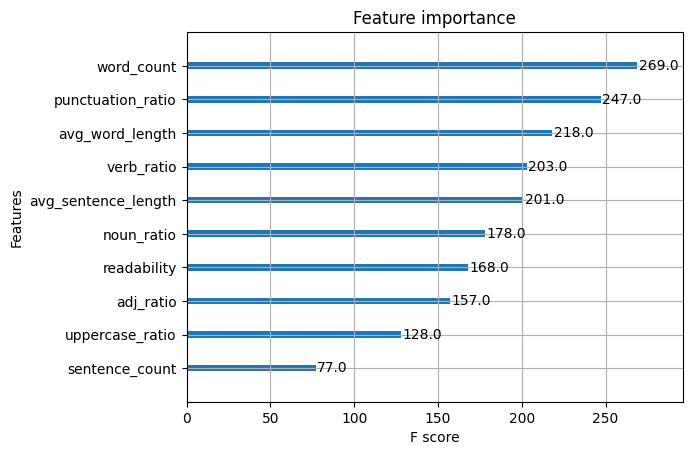

In [77]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance Plot
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model)
plt.show()